# H10 — Notification Frequency and Retention

## 1. Business Question

**Does notification frequency influence user retention?**

### Hypothesis

User retention is associated with notification frequency.

### Analytical objective

Determine whether notification exposure is associated with retention at user level, while distinguishing:

- descriptive association,
- statistical evidence,
- confounding by transaction activity,
- practical relevance,
- and causality.

This analysis does not establish that sending more notifications causes retention.


## 2. Analytical Setup

### Unit of analysis

**One row per user.**

### Definitions

**Retained user**

A user who completes successful-transaction activity in three consecutive completed calendar months, and then maintains activity in each subsequent completed month as required by the approved retention model. Users who have never activated are forced to `FALSE`.

**Notification frequency**

Number of notifications with status `SENT` received by the user. This measures exposure / delivery, not opens or clicks.

### Analytical variables

| Variable | Meaning |
|---|---|
| `user_id` | Unique user identifier |
| `retention_flag` | User-level retention classification |
| `notification_frequency` | Count of SENT notifications |
| `transaction_frequency` | Successful transaction count (confounder / activity control) |
| `plan_segment` | STANDARD / PREMIUM |

The analysis uses the validated `mart_retention` table in BigQuery. Notification counts are produced by `int_notification_activity` (`COUNTIF(status = 'SENT')`) and joined through `int_user_activity`.


## 3. Data and Analytical Population

Before comparison, the notebook verifies grain, missingness, and base rates.


In [1]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

client = bigquery.Client(project="le-wagon-da-502302")

query = '''
SELECT
    user_id,
    retention_flag,
    notification_frequency,
    transaction_frequency,
    plan_segment
FROM `le-wagon-da-502302.NeoBank.mart_retention`
'''

df = client.query(query).to_dataframe()

expected = {"user_id", "retention_flag", "notification_frequency", "transaction_frequency", "plan_segment"}
missing = expected - set(df.columns)
if missing:
    raise ValueError(f"Missing columns: {sorted(missing)}")

if len(df) != df["user_id"].nunique():
    raise ValueError("mart_retention is not one row per user.")

df["retention_flag"] = df["retention_flag"].astype(bool)

print("Mart shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())
print("\nRetention distribution:")
print(df["retention_flag"].value_counts())
print("\nRetention rate:", df["retention_flag"].mean())


Mart shape: (19430, 5)

Missing values:
user_id                     0
retention_flag              0
notification_frequency    477
transaction_frequency     664
plan_segment                0
dtype: int64

Retention distribution:
retention_flag
False    11157
True      8273
Name: count, dtype: int64

Retention rate: 0.42578486875965005


In [2]:
# Primary population: users with non-null notification_frequency
# (NULL means no rows in stg_notifications for that user)
analysis = df.dropna(subset=["notification_frequency"]).copy()
print("Primary analytical population:", len(analysis))
print("Retention rate (primary):", analysis["retention_flag"].mean())
print("\nNotification frequency summary:")
print(analysis["notification_frequency"].describe())


Primary analytical population: 18953
Retention rate (primary): 0.43159394291141245

Notification frequency summary:
count   18,953.0000
mean         4.7210
std          2.7474
min          0.0000
25%          3.0000
50%          4.0000
75%          6.0000
max         20.0000
Name: notification_frequency, dtype: Float64


## 4. Descriptive Evidence

Notification counts are compared between retained and non-retained users. Counts are skewed, so medians and distributional tests are preferred over means alone.


In [3]:
summary = (
    analysis.groupby("retention_flag")["notification_frequency"]
    .agg(
        users="count",
        mean="mean",
        median="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        maximum="max",
    )
)
summary


,users,mean,median,q1,q3,maximum
retention_flag,,,,,,
False,10773,4.5109,4.0000,3,6,20
True,8180,4.9977,5.0000,3,7,18


In [4]:
retained = analysis.loc[analysis["retention_flag"], "notification_frequency"]
not_retained = analysis.loc[~analysis["retention_flag"], "notification_frequency"]

u_stat, p_value = stats.mannwhitneyu(retained, not_retained, alternative="two-sided")
r_pb, p_pb = stats.pointbiserialr(
    analysis["retention_flag"].astype(int),
    analysis["notification_frequency"].astype(float),
)

print(f"Median retained:     {retained.median():.1f}")
print(f"Median not retained: {not_retained.median():.1f}")
print(f"Absolute median gap: {retained.median() - not_retained.median():.1f}")
print(f"Mann-Whitney U = {u_stat:,.1f}, p = {p_value:.4g}")
print(f"Point-biserial r = {r_pb:.4f}, p = {p_pb:.4g}")


Median retained:     5.0
Median not retained: 4.0
Absolute median gap: 1.0
Mann-Whitney U = 49,328,797.5, p = 7.658e-46
Point-biserial r = 0.0878, p = 1.006e-33


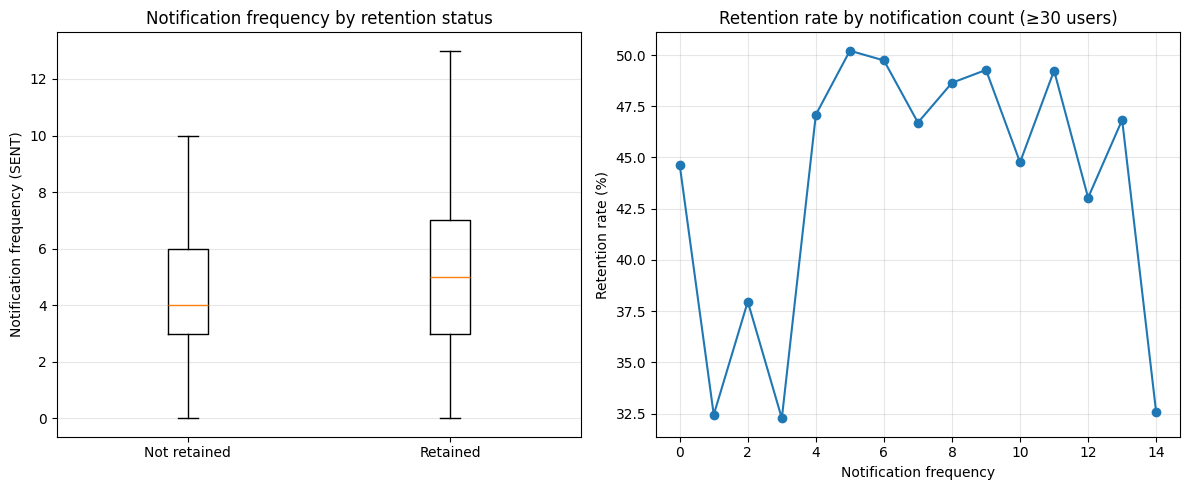

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: boxplot of notification frequency by retention
data_box = [not_retained.astype(float), retained.astype(float)]
axes[0].boxplot(data_box, tick_labels=["Not retained", "Retained"], showfliers=False)
axes[0].set_ylabel("Notification frequency (SENT)")
axes[0].set_title("Notification frequency by retention status")
axes[0].grid(True, axis="y", alpha=0.3)

# Right: retention rate by notification count (dose)
dose = (
    analysis.groupby("notification_frequency")
    .agg(users=("user_id", "count"), rate=("retention_flag", "mean"))
    .reset_index()
)
dose_plot = dose[dose["users"] >= 30]
axes[1].plot(dose_plot["notification_frequency"], dose_plot["rate"] * 100, marker="o")
axes[1].set_xlabel("Notification frequency")
axes[1].set_ylabel("Retention rate (%)")
axes[1].set_title("Retention rate by notification count (≥30 users)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Retained users show a slightly higher notification frequency (median 5 vs 4). The difference is statistically significant but small. The dose curve rises from the lowest counts and then flattens around 47–50% retention from about four notifications upward. This is not a strong linear “more messages → more retention” pattern.


## 5. Activity Confounding

Transaction frequency differs sharply between retained and non-retained users. If notification volume mainly tracks overall activity, the univariate association may not be an independent notification effect.


In [6]:
tx = analysis.dropna(subset=["transaction_frequency"]).copy()
print("Transaction frequency by retention:")
print(
    tx.groupby("retention_flag")["transaction_frequency"]
    .agg(["count", "mean", "median", "std"])
)

rho, rho_p = stats.spearmanr(tx["notification_frequency"], tx["transaction_frequency"])
print(f"\nSpearman(notification, transaction) = {rho:.4f}, p = {rho_p:.4g}")


Transaction frequency by retention:
                count     mean   median      std
retention_flag                                  
False           10157  41.1868  17.0000  72.7513
True             8180 239.7758 139.0000 296.8650

Spearman(notification, transaction) = 0.1155, p = 1.621e-55


In [7]:
# Retention by notification band within transaction tertiles
tx["tx_tert"] = pd.qcut(
    tx["transaction_frequency"].rank(method="first"),
    3,
    labels=["low_tx", "mid_tx", "high_tx"],
)
tx["notif_band"] = pd.cut(
    tx["notification_frequency"],
    bins=[-0.1, 3, 6, 20],
    labels=["0-3", "4-6", "7+"],
)

ct = (
    tx.groupby(["tx_tert", "notif_band"], observed=True)
    .agg(users=("user_id", "count"), ret_rate=("retention_flag", "mean"))
    .reset_index()
)
ct["ret_pct"] = ct["ret_rate"] * 100
ct


,tx_tert,notif_band,users,ret_rate,ret_pct
0,low_tx,0-3,2775,0.0472,4.7207
1,low_tx,4-6,2058,0.0802,8.0175
2,low_tx,7+,1279,0.0977,9.7733
3,mid_tx,0-3,2030,0.4074,40.7389
4,mid_tx,4-6,2371,0.4686,46.8579
5,mid_tx,7+,1711,0.4372,43.7171
6,high_tx,0-3,1907,0.8238,82.3807
7,high_tx,4-6,2552,0.8519,85.1881
8,high_tx,7+,1654,0.8029,80.2902


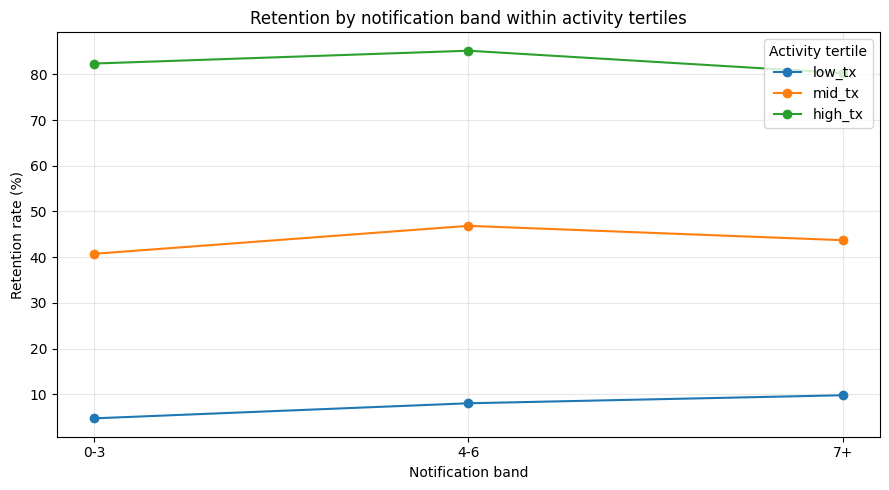

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
for tert in ["low_tx", "mid_tx", "high_tx"]:
    sub = ct[ct["tx_tert"] == tert]
    ax.plot(sub["notif_band"].astype(str), sub["ret_pct"], marker="o", label=tert)
ax.set_ylabel("Retention rate (%)")
ax.set_xlabel("Notification band")
ax.set_title("Retention by notification band within activity tertiles")
ax.legend(title="Activity tertile")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Within each activity tertile, notification bands only move retention by a few percentage points. The dominant separation is activity itself (low-activity retention near single digits to low teens in the lowest band group versus ~80%+ in the highest activity tertile). Notification volume is not the main driver.


## 6. Multivariate Evidence

A logistic model predicts retention from notification frequency and log transaction frequency. This tests whether notifications retain an association after activity is controlled.


In [9]:
dtx = analysis.dropna(subset=["transaction_frequency"]).copy()
dtx["y"] = dtx["retention_flag"].astype(int)
dtx["notif"] = dtx["notification_frequency"].astype(float)
dtx["log_tx"] = np.log1p(dtx["transaction_frequency"].astype(float))

# Univariate notification model
X1 = sm.add_constant(dtx[["notif"]])
m1 = sm.Logit(dtx["y"], X1).fit(disp=0)

# Multivariate model
X2 = sm.add_constant(dtx[["notif", "log_tx"]])
m2 = sm.Logit(dtx["y"], X2).fit(disp=0)

print("Univariate notification model")
print(m1.summary2().tables[1])
print(f"\nUnivariate notif OR = {np.exp(m1.params['notif']):.4f}")

print("\nMultivariate model (notif + log1p(transaction_frequency))")
print(m2.summary2().tables[1])
print(f"\nMultivariate notif OR = {np.exp(m2.params['notif']):.4f}")
print(f"Multivariate log_tx OR = {np.exp(m2.params['log_tx']):.4f}")


Univariate notification model
        Coef.  Std.Err.        z  P>|z|  [0.025  0.975]
const -0.4577    0.0300 -15.2784 0.0000 -0.5164 -0.3990
notif  0.0502    0.0054   9.3096 0.0000  0.0397  0.0608

Univariate notif OR = 1.0515

Multivariate model (notif + log1p(transaction_frequency))
         Coef.  Std.Err.        z  P>|z|  [0.025  0.975]
const  -5.5399    0.0902 -61.3956 0.0000 -5.7168 -5.3631
notif   0.0077    0.0070   1.0977 0.2723 -0.0061  0.0215
log_tx  1.3286    0.0199  66.8955 0.0000  1.2896  1.3675

Multivariate notif OR = 1.0078
Multivariate log_tx OR = 3.7756


In [10]:
# STANDARD plan only (main population)
std = dtx[dtx["plan_segment"] == "STANDARD"].copy()
X = sm.add_constant(std[["notif", "log_tx"]])
m_std = sm.Logit(std["y"], X).fit(disp=0)
print("STANDARD plan — multivariate")
print(m_std.summary2().tables[1])
print(f"\nSTANDARD notif OR = {np.exp(m_std.params['notif']):.4f}, p = {m_std.pvalues['notif']:.4g}")


STANDARD plan — multivariate
         Coef.  Std.Err.        z  P>|z|  [0.025  0.975]
const  -5.5508    0.0931 -59.6187 0.0000 -5.7333 -5.3683
notif  -0.0039    0.0074  -0.5296 0.5964 -0.0184  0.0106
log_tx  1.3309    0.0205  64.9515 0.0000  1.2908  1.3711

STANDARD notif OR = 0.9961, p = 0.5964


Univariate models show a small positive notification association. After controlling for transaction activity, the notification coefficient is consistent with no effect (odds ratio ≈ 1.0, not statistically significant). In the STANDARD population the notification coefficient remains null. Transaction activity remains the dominant predictor.


## 7. Low-Activity Segment and Message Context

Even among the lowest-activity users — the segment messaging is often intended to help — higher notification volume does not produce material retention. Message reasons with high recipient retention also show high median transaction counts, which is consistent with targeting already-active users rather than a causal volume effect.


In [11]:
u = analysis.dropna(subset=["transaction_frequency"]).copy()
u["tx_band"] = pd.qcut(
    u["transaction_frequency"].rank(method="first"),
    4,
    labels=["Q1_lowest", "Q2", "Q3", "Q4_highest"],
)

print("Retention by activity quartile:")
print(
    u.groupby("tx_band", observed=True)
    .agg(users=("user_id", "count"), retention=("retention_flag", "mean"))
    .assign(ret_pct=lambda x: x["retention"] * 100)
)

low = u[u["tx_band"] == "Q1_lowest"].copy()
low["notif_band"] = pd.cut(
    low["notification_frequency"],
    bins=[-0.1, 2, 4, 6, 20],
    labels=["0-2", "3-4", "5-6", "7+"],
)
print("\nLowest-activity quartile — retention by notification band:")
print(
    low.groupby("notif_band", observed=True)
    .agg(users=("user_id", "count"), retention=("retention_flag", "mean"))
    .assign(ret_pct=lambda x: x["retention"] * 100)
)


Retention by activity quartile:
            users  retention  ret_pct
tx_band                              
Q1_lowest    4585     0.0275   2.7481
Q2           4584     0.3039  30.3883
Q3           4584     0.5807  58.0716
Q4_highest   4584     0.8724  87.2382

Lowest-activity quartile — retention by notification band:
            users  retention  ret_pct
notif_band                           
0-2          1254     0.0136   1.3557
3-4          1539     0.0221   2.2092
5-6           887     0.0451   4.5096
7+            905     0.0387   3.8674


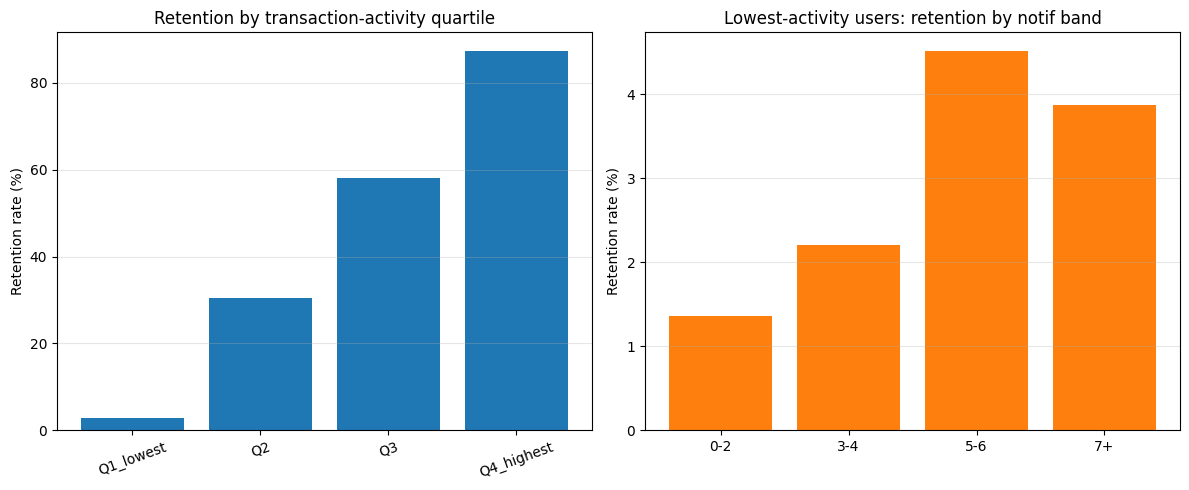

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Activity quartile retention
band_ret = (
    u.groupby("tx_band", observed=True)["retention_flag"].mean() * 100
)
axes[0].bar(band_ret.index.astype(str), band_ret.values, color="#1f77b4")
axes[0].set_ylabel("Retention rate (%)")
axes[0].set_title("Retention by transaction-activity quartile")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(True, axis="y", alpha=0.3)

# Low-activity notif bands
low_ret = (
    low.groupby("notif_band", observed=True)["retention_flag"].mean() * 100
)
axes[1].bar(low_ret.index.astype(str), low_ret.values, color="#ff7f0e")
axes[1].set_ylabel("Retention rate (%)")
axes[1].set_title("Lowest-activity users: retention by notif band")
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Interpretation

### Descriptive association

Retained users receive slightly more SENT notifications (median 5 vs 4). The univariate association is statistically significant and small in magnitude.

### Confounding

Transaction activity is strongly related to retention and weakly related to notification volume. Within activity bands, notification volume adds little. Multivariate logistic regression removes the notification association.

### Practical relevance

A one-notification median gap and a null multivariate odds ratio do not support treating notification volume as a retention lever.

### Causality

This is observational. The data do not show that increasing notification volume improves retention. Message content and targeting may still matter operationally; volume alone is not supported here.


## 9. Final Finding

### H10 — Partially supported / qualified association

Notification frequency is weakly associated with retention in univariate comparisons. After controlling for transaction activity, notification frequency is **not** meaningfully associated with retention.

The evidence does **not** support increasing notification volume as a retention strategy.

### Business-story handoff

Evidence that should move into the Notion knowledge / business layer:

- the weak univariate association (median 5 vs 4);
- the dominant role of transaction activity;
- the null multivariate notification effect;
- the flat response among low-activity users;
- the implication that onboarding-friction cohorts (`NO_INITIAL_*`) are a product investigation, not a CRM volume problem;
- and the recommendation that any messaging test should use holdouts and target content/timing — not higher send volume for everyone.

Final prioritisation and roadmap decisions belong in the presentation / business-story layer, not in this evidence notebook.
